<a href="https://colab.research.google.com/github/rohanbhangale/mldl_exps/blob/main/mldl_exp_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Preview:
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0    

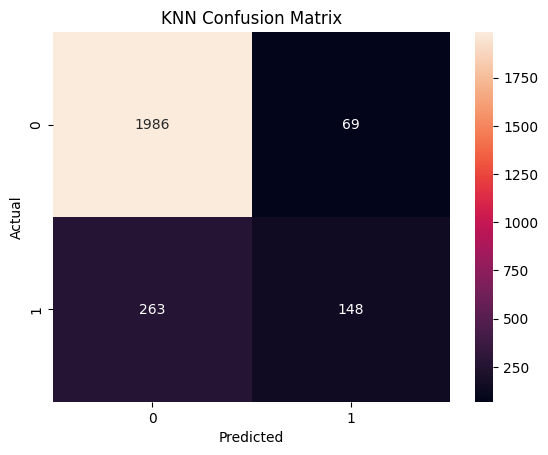

In [2]:
# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ===============================
# 2. Load Dataset
# ===============================

df = pd.read_csv("online_shoppers_intention.csv")

print("Dataset Preview:")
print(df.head())

# ===============================
# 3. Data Preprocessing
# ===============================

# Encode categorical columns
le = LabelEncoder()

categorical_cols = ['Month', 'VisitorType', 'Weekend', 'Revenue']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Features and Target
X = df.drop('Revenue', axis=1)
y = df['Revenue']

# ===============================
# 4. Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 5. Feature Scaling (IMPORTANT for KNN)
# ===============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# 6. KNN Model
# ===============================
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

# ===============================
# 7. Evaluation
# ===============================
print("\nKNN Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ===============================
# 8. Confusion Matrix
# ===============================
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Distribution of the Target Variable (Revenue)

Let's visualize the distribution of the `Revenue` column to understand the class balance in our dataset.

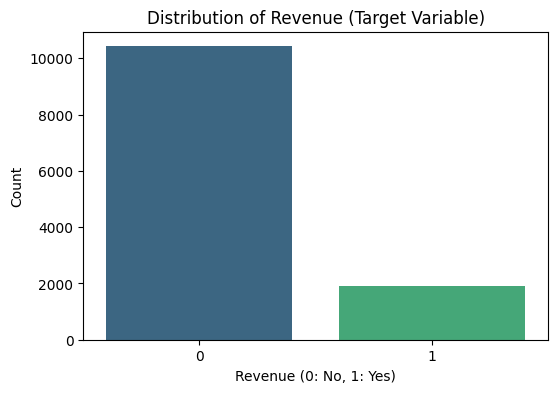

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='viridis', hue=y, legend=False)
plt.title('Distribution of Revenue (Target Variable)')
plt.xlabel('Revenue (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

### Classification Report Metrics Visualization

To make the classification report more visual, let's plot the precision, recall, and F1-score for each class.

<Figure size 1000x600 with 0 Axes>

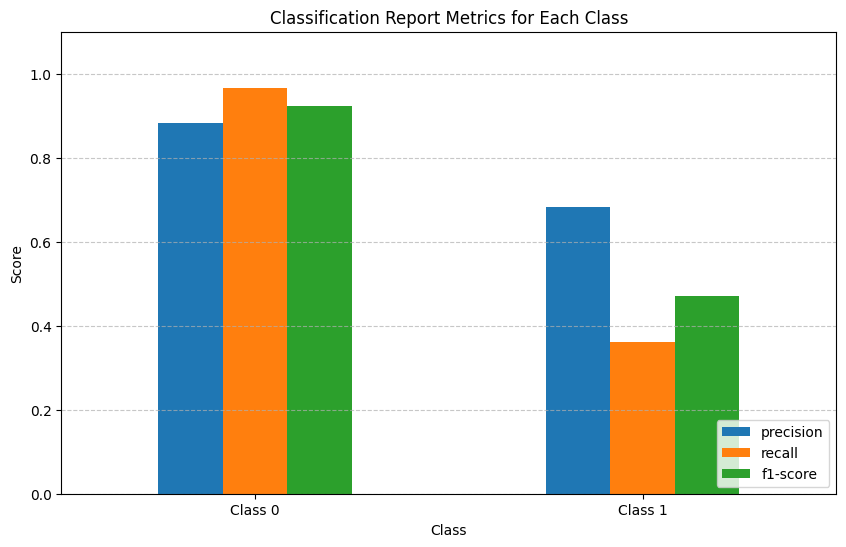

In [4]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)

# Extract metrics for class 0 and 1
class_0_metrics = {k: v for k, v in report['0'].items() if k not in ['support']}
class_1_metrics = {k: v for k, v in report['1'].items() if k not in ['support']}

metrics_df = pd.DataFrame({'Class 0': class_0_metrics, 'Class 1': class_1_metrics})

metrics_df = metrics_df.transpose().reset_index()
metrics_df.rename(columns={'index': 'Class'}, inplace=True)

plt.figure(figsize=(10, 6))
metrics_df.set_index('Class').plot(kind='bar', figsize=(10, 6))
plt.title('Classification Report Metrics for Each Class')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1.1) # Set y-axis limit from 0 to 1.1 for better visualization of scores
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()